In [2]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [3]:
trades.head()
sentiment.head()

trades.columns
sentiment.columns


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [4]:
print("Sentiment Min Date:", sentiment['date'].min())
print("Sentiment Max Date:", sentiment['date'].max())

print("Trades Min Date:", trades['date'].min())
print("Trades Max Date:", trades['date'].max())

Sentiment Min Date: 2018-02-01
Sentiment Max Date: 2025-05-02


KeyError: 'date'

In [5]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date

In [6]:
print(trades[['Timestamp IST', 'date']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [7]:
print("Trades Min Date:", trades['date'].min())
print("Trades Max Date:", trades['date'].max())

Trades Min Date: 2023-05-01
Trades Max Date: 2025-05-01


In [8]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [9]:
print(merged['classification'].value_counts())

Series([], Name: count, dtype: int64)


In [10]:
print(trades['date'].head())
print(type(trades['date'].iloc[0]))

print("\n---\n")

print(sentiment['date'].head())
print(type(sentiment['date'].iloc[0]))

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object
<class 'datetime.date'>

---

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
<class 'str'>


In [11]:
print(trades['date'].nunique())
print(sentiment['date'].nunique())

480
2644


In [12]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [13]:
print(type(sentiment['date'].iloc[0]))

<class 'datetime.date'>


In [14]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [15]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [16]:
merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

,Closed PnL
classification,
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Extreme Fear,34.537862
Neutral,34.307718


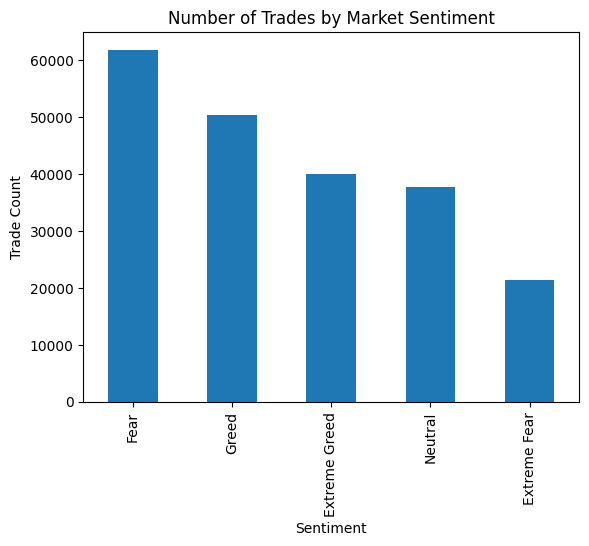

In [17]:
import matplotlib.pyplot as plt

merged['classification'].value_counts().plot(kind='bar')

plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trade Count')
plt.show()


In [18]:
merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

,Closed PnL
classification,
Fear,3.357155e+06
Extreme Greed,2.715171e+06
Greed,2.150129e+06
Neutral,1.292921e+06
Extreme Fear,7.391102e+05


In [19]:
merged['win'] = merged['Closed PnL'] > 0

merged.groupby('classification')['win'].mean().sort_values(ascending=False)

,win
classification,
Extreme Greed,0.464943
Fear,0.420768
Neutral,0.396991
Greed,0.384828
Extreme Fear,0.370607


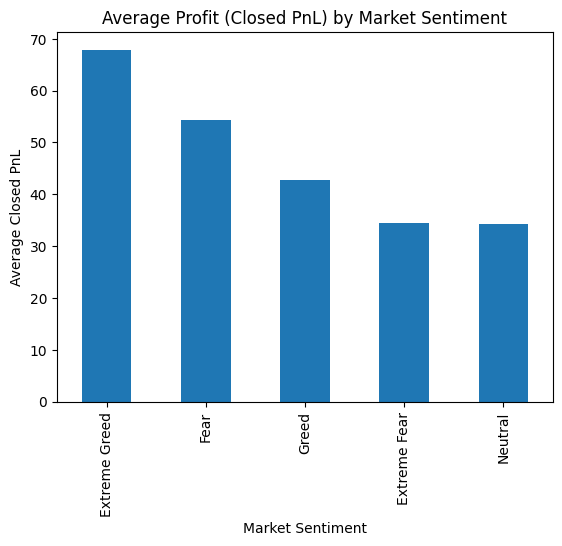

In [20]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

avg_pnl.plot(kind='bar')

plt.title('Average Profit (Closed PnL) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

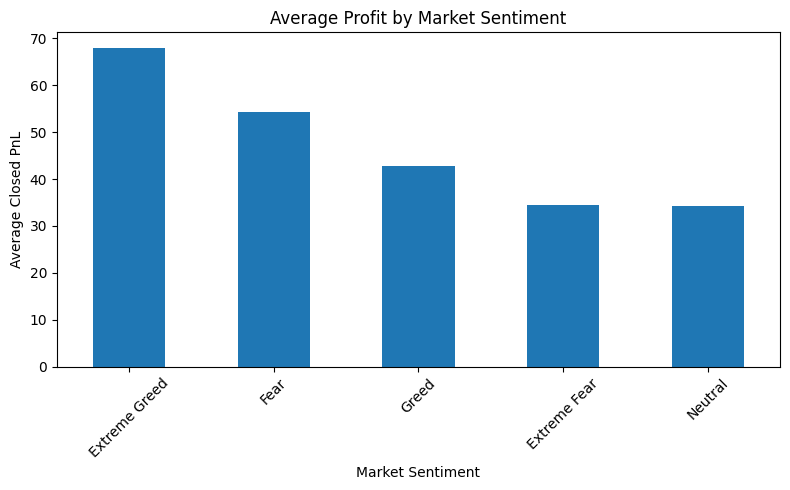

In [21]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
merged.groupby('classification')['Size USD'].mean().sort_values(ascending=False)

,Size USD
classification,
Fear,7816.109931
Greed,5736.884375
Extreme Fear,5349.731843
Neutral,4782.732661
Extreme Greed,3112.251565


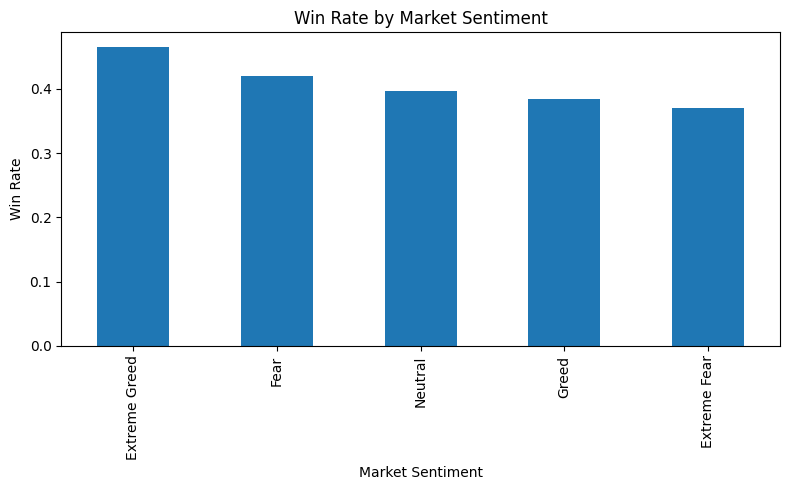

In [23]:
win_rate = merged.groupby('classification')['win'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')

plt.tight_layout()
plt.show()